# Imbalanced classification

## Project: german credit classification

This is a modified version of the project in Jason Brownlee's e-book, _Imbalanced Classification with Python_.

In [1]:
from collections import Counter

from imblearn.pipeline import Pipeline as ImblearnPipeline
from imblearn.under_sampling import (
    EditedNearestNeighbours,
    NeighbourhoodCleaningRule,
    OneSidedSelection,
    RepeatedEditedNearestNeighbours,
    TomekLinks,
)
from matplotlib import pyplot
from numpy import mean, std
from pandas import read_csv
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC

### Load and explore the data

In [2]:
# define the dataset location
full_path = "data/german.csv"
# load the csv file as a data frame
dataframe = read_csv(full_path, header=None)
# summarize the shape of the dataset
print(dataframe.shape)

(1000, 21)


In [3]:
# summarize the class distribution
target = dataframe.values[:, -1]
counter = Counter(target)
for k, v in counter.items():
    per = v / len(target) * 100
    print("Class=%s, Count=%d, Percentage=%.3f%%" % (k, v, per))

Class=good, Count=700, Percentage=70.000%
Class=bad, Count=300, Percentage=30.000%


Mild imbalance between good and bad bank creditors.

Some of the predictors are numerical (7) and the others are categorical (13).

A complete description of this dataset can be found at
https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data).

In the context of these data, false negatives are more expensive than false
positives with a 5:1 cost ratio.

To reflect this fact, we will use the F2 score as our evaluation metric
for the models.

### Create a baseline model

Some utility functions.

Note that we use stratified cross-validation to ensure that the distribution
of class labels in each fold is the same as the distribution of the class
labels in the full dataset.

In [4]:
# load the dataset
def load_dataset(full_path):
    # load the dataset as a numpy array
    dataframe = read_csv(full_path, header=None)
    # split into inputs and outputs
    last_ix = len(dataframe.columns) - 1
    X, y = dataframe.drop(last_ix, axis=1), dataframe[last_ix]
    # select categorical features
    cat_ix = X.select_dtypes(include=["object", "bool"]).columns
    # one hot encode cat features only
    ct = ColumnTransformer([("o", OneHotEncoder(), cat_ix)], remainder="passthrough")
    X = ct.fit_transform(X)
    # label encode the target variable to have the classes 0 and 1
    y = LabelEncoder().fit_transform(y)
    # patch: make it so that 'bad' is the category mapped to 1
    y = -y + 1
    return X, y


# calculate f2-measure
def f2_measure(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)


# evaluate a model
def evaluate_model(X, y, model):
    # define evaluation procedure
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    # define the model evaluation metric
    metric = make_scorer(f2_measure)
    # evaluate model
    scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
    return scores

In [5]:
# load the dataset
X, y = load_dataset(full_path)
# summarize the loaded dataset
print(X.shape, y.shape, Counter(y))
# define the reference model
model = DummyClassifier(strategy="constant", constant=1)
# evaluate the model
scores = evaluate_model(X, y, model)
baseline_performance = mean(scores)
# summarize performance
print("Mean F2: %.3f (%.3f)" % (baseline_performance, std(scores)))

(1000, 61) (1000,) Counter({0: 700, 1: 300})
Mean F2: 0.682 (0.000)


Note that we are using a `DummyClassifier` that always predicts the minority
class (bad customer).

This is a reasonable baseline because it maximizes recall (it completely
avoids false negatives, which are most expensive in this application)
while establishing a baseline for precision.

### Try out some models

Utility function.

In [7]:
# load the dataset
def load_dataset(full_path):
    # load the dataset as a numpy array
    dataframe = read_csv(full_path, header=None)
    # split into inputs and outputs
    last_ix = len(dataframe.columns) - 1
    X, y = dataframe.drop(last_ix, axis=1), dataframe[last_ix]
    # select categorical and numerical features
    cat_ix = X.select_dtypes(include=["object", "bool"]).columns
    num_ix = X.select_dtypes(include=["int64", "float64"]).columns
    # label encode the target variable to have the classes 0 and 1
    y = LabelEncoder().fit_transform(y)
    # patch: make it so that 'bad' is the category mapped to 1
    y = -y + 1
    return X.values, y, cat_ix, num_ix


# define models to test
def get_models():
    models, names = list(), list()
    # LR
    models.append(LogisticRegression(solver="liblinear", class_weight="balanced"))
    names.append("LR")
    # LDA
    models.append(LinearDiscriminantAnalysis())
    names.append("LDA")
    # NB
    models.append(GaussianNB())
    names.append("NB")
    # SVM
    models.append(SVC(gamma="scale"))
    names.append("SVM")
    return models, names

Note that the models do not require tuning, so the cross-validation error
is a honest estimate of the generalization error of these models
(in this case measured in terms of the F2 score).

>LR 0.662 (0.062)
>LDA 0.519 (0.072)
>NB 0.639 (0.049)
>SVM 0.434 (0.089)


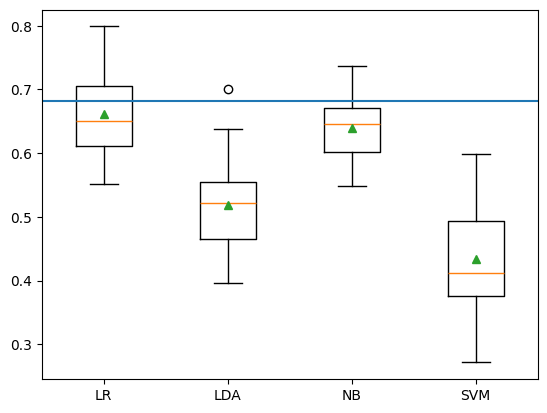

In [8]:
# load the dataset
X, y, cat_ix, num_ix = load_dataset(full_path)
# define models
models, names = get_models()
results = list()
# evaluate each model
for i in range(len(models)):
    # one hot encode categorical, normalize numerical
    ct = ColumnTransformer(
        [("c", OneHotEncoder(), cat_ix), ("n", StandardScaler(), num_ix)]
    )
    # wrap the model in a pipeline
    pipeline = Pipeline(steps=[("t", ct), ("m", models[i])])
    # evaluate the model and store results
    scores = evaluate_model(X, y, pipeline)
    results.append(scores)
    # summarize and store
    print(">%s %.3f (%.3f)" % (names[i], mean(scores), std(scores)))
# plot the results
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.axhline(baseline_performance)
pyplot.show()

Note that in the case of the Naive Bayes classifier we are really abusing
the model: 13 of the predictors are categorical (so clearly not Gaussian!)
and we haven't investigated whether the remaining 7 numeric predictors
are approximately Gaussian...

### Try over/undersampling

Let's see if we can improve this by means of over/undersampling.

In [9]:
# define undersampling models to test
def get_models():
    models, names = list(), list()
    # TL
    models.append(TomekLinks())
    names.append("TL")
    # ENN
    models.append(EditedNearestNeighbours())
    names.append("ENN")
    # RENN
    models.append(RepeatedEditedNearestNeighbours())
    names.append("RENN")
    # OSS
    models.append(OneSidedSelection())
    names.append("OSS")
    # NCR
    models.append(NeighbourhoodCleaningRule())
    names.append("NCR")
    return models, names

>TL 0.666 (0.061)
>ENN 0.706 (0.054)
>RENN 0.710 (0.051)
>OSS 0.665 (0.062)
>NCR 0.681 (0.055)


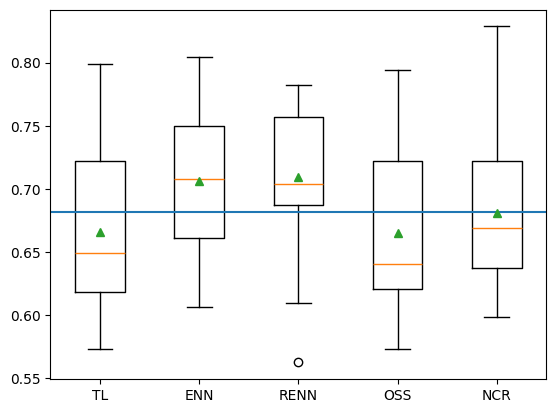

In [10]:
# define models
models, names = get_models()
results = list()
# evaluate each model
for i in range(len(models)):
    # define model to evaluate
    model = LogisticRegression(solver="liblinear", class_weight="balanced")
    # one hot encode categorical, normalize numerical
    ct = ColumnTransformer(
        [("c", OneHotEncoder(), cat_ix), ("n", StandardScaler(), num_ix)]
    )
    # scale, then undersample, then fit model
    pipeline = ImblearnPipeline(steps=[("t", ct), ("s", models[i]), ("m", model)])
    # evaluate the model and store results
    scores = evaluate_model(X, y, pipeline)
    results.append(scores)
    # summarize and store
    print(">%s %.3f (%.3f)" % (names[i], mean(scores), std(scores)))
# plot the results
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.axhline(baseline_performance)
pyplot.show()

It seems that ENN/RENN might be beneficial in this case.